# Tamrra AI – Date Fruit Classification & Nutrition Assistant
### Author: Abderrahmane
### Project: Computer Vision on Date Fruits
### Date: 2026-02-12

In [ ]:
# 🔹 Core PyTorch & TorchVision
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

# 🔹 Data Handling & Visualization
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 🔹 Dataset splitting & file operations
from sklearn.model_selection import train_test_split
import os
import shutil
import random

# 🔹 KaggleHub for dataset download
import kagglehub

In [ ]:
# # Please uncomment this out when you are running this lab on google colab!
import os

# # Set KaggleHub cache to a directory inside /content/
os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [ ]:
import os
import shutil
from pathlib import Path
import kagglehub

# Base paths
BASE_DIR = Path().resolve().parent  # ai/
DATASET_DIR = BASE_DIR / "dataset"
RAW_DIR = DATASET_DIR / "raw"

# create dataset/raw if not exists
RAW_DIR.mkdir(parents=True, exist_ok=True)

# download (cached)
downloaded_path = kagglehub.dataset_download(
    "wadhasnalhamdan/date-fruit-image-dataset-in-controlled-environment"
)

print("Downloaded to cache:", downloaded_path)

# copy only if raw is empty (avoid overwrite)
if not any(RAW_DIR.iterdir()):
    shutil.copytree(downloaded_path, RAW_DIR, dirs_exist_ok=True)
    print(f"Copied dataset to {RAW_DIR}")
else:
    print(f"Dataset already exists in {RAW_DIR}, skipping copy")

100%|██████████| 3.11G/3.11G [00:40<00:00, 83.4MB/s]

Extracting files...


Path to dataset files: /content/data/datasets/wadhasnalhamdan/date-fruit-image-dataset-in-controlled-environment/versions/1


###Dataset Paths & Folder Structure

In [ ]:
PROCESSED_DIR = DATASET_DIR / "processed"

train_dir = PROCESSED_DIR / "train"
val_dir   = PROCESSED_DIR / "val"
test_dir  = PROCESSED_DIR / "test"

for folder in [train_dir, val_dir, test_dir]:
    folder.mkdir(parents=True, exist_ok=True)

In [ ]:
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

###Split Dataset into Train/Val/Test

In [ ]:
from sklearn.model_selection import train_test_split
import os
import shutil

original_dataset_dir = RAW_DIR  # dataset/raw

# safety check (ما يعيد split)
if any(train_dir.iterdir()):
    print("Dataset already split. Skipping...")
else:
    for class_name in os.listdir(original_dataset_dir):

        class_path = os.path.join(original_dataset_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)

        # split: 70 / 15 / 15
        train_imgs, temp_imgs = train_test_split(
            images,
            test_size=0.3,
            random_state=42
        )

        val_imgs, test_imgs = train_test_split(
            temp_imgs,
            test_size=0.5,
            random_state=42
        )

        splits = {
            train_dir: train_imgs,
            val_dir: val_imgs,
            test_dir: test_imgs
        }

        for split_path, img_list in splits.items():

            split_class_dir = split_path / class_name
            split_class_dir.mkdir(parents=True, exist_ok=True)

            for img in img_list:
                src = os.path.join(class_path, img)
                dst = split_class_dir / img

                shutil.copy(src, dst)

    print("Dataset split completed.")

###Data Augmentation & DataLoader Setup

In [ ]:
# ==========================================
# 🔹 Tamrra AI – Data Augmentation & DataLoader
# Description:
# Prepare PyTorch transforms, datasets, and dataloaders for training, validation, and testing.
# Apply data augmentation to training set to reduce overfitting.
# ==========================================

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# 🔹 1️⃣ Training transforms (data augmentation)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),        # Random crop + resize to 224x224
    transforms.RandomHorizontalFlip(),       # Random horizontal flip
    transforms.RandomRotation(20),           # Random rotation ±20 degrees
    transforms.ColorJitter(0.3,0.3,0.3),    # Random brightness, contrast, saturation
    transforms.ToTensor(),                   # Convert image to PyTorch Tensor
    transforms.Normalize(mean=[0.485,0.456,0.406], # Normalize using ImageNet stats
                         std=[0.229,0.224,0.225])
])

# 🔹 2️⃣ Validation & Test transforms (no augmentation, deterministic)
test_transform = transforms.Compose([
    transforms.Resize(256),                  # Resize smaller edge to 256
    transforms.CenterCrop(224),              # Crop center to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# 🔹 3️⃣ Create Datasets
# **Note:** ImageFolder reads images from class-labeled folders
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = ImageFolder(val_dir, transform=test_transform)
test_dataset = ImageFolder(test_dir, transform=test_transform)

# 🔹 4️⃣ Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Shuffle training for randomness
val_loader = DataLoader(val_dataset, batch_size=32)                     # No shuffle for validation
test_loader = DataLoader(test_dataset, batch_size=32)                   # No shuffle for testing

print("✅ Datasets and DataLoaders are ready.")

In [ ]:
print(train_dataset.class_to_idx)
print(len(train_dataset))
print(len(val_dataset))

{'Ajwa': 0, 'Galaxy': 1, 'Medjool': 2, 'Meneifi': 3, 'Nabtat Ali': 4, 'Rutab': 5, 'Shaishe': 6, 'Sokari': 7, 'Sugaey': 8}
1156
249


# Let display same images

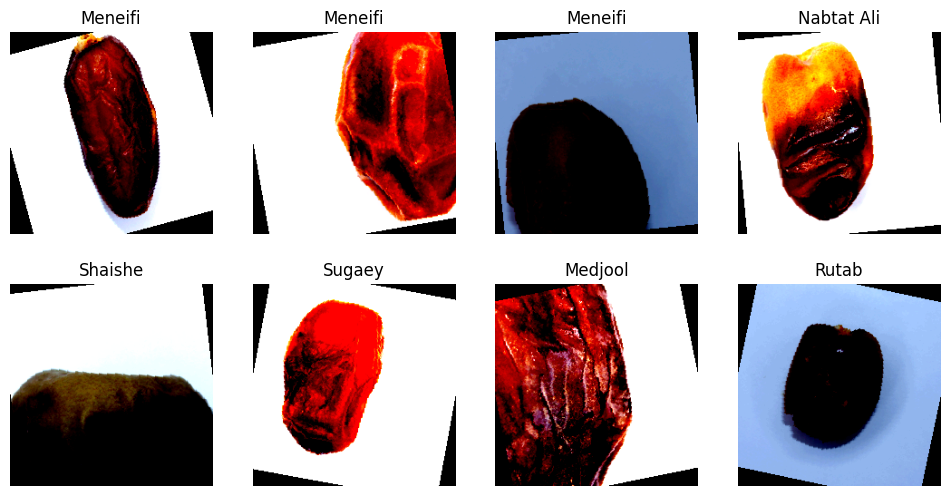

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Date classes
classes = ['Ajwa', 'Galaxy', 'Medjool', 'Meneifi', 'Nabtat Ali',
           'Rutab', 'Shaishe', 'Sokari', 'Sugaey']

# Display first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C)
    img = np.clip(img, 0, 1)  # clip values for display

    ax.imshow(img)
    ax.set_title(classes[labels[i].item()])
    ax.axis('off')

plt.show()

###Model Definition (EfficientNet-B0)

In [ ]:
from torchvision import models
import torch.nn as nn
import torch

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)

# Freeze backbone features (optional for small datasets)
for param in model.features.parameters():
    param.requires_grad = False

# Modify classifier for 9 classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 9)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 188MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

###Training & Validation Loops

In [ ]:
from tqdm import tqdm    # Shows progress bar

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)


        outputs = model(images).squeeze()  # The model outputs in shape [batch_size,1]. We convert them to [batch_size,] so the loss accepts them.
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Track accuracy
        _, predictions = torch.max(outputs, 1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).squeeze()  # The model outputs in shape [batch_size,1]. We convert them to [batch_size,] so the loss accepts them.
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Compute accuracy
            _, predictions = torch.max(outputs, 1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


###Training Process & Metrics Logging

In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Binary Classification loss (Use when there is no softmax/sigmoid in the last layer)
optimizer = optim.AdamW(model.parameters(), lr=0.001)  # Adam optimizer
num_epochs = 10 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, val_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")


100%|██████████| 37/37 [02:04<00:00,  3.36s/it]


Epoch 1/10: Train Loss=1.7787, Train Accuracy=40.92%, Val Loss=1.2528, Val Accuracy=77.91%


100%|██████████| 37/37 [02:02<00:00,  3.30s/it]


Epoch 2/10: Train Loss=1.2390, Train Accuracy=67.82%, Val Loss=0.9190, Val Accuracy=82.73%


100%|██████████| 37/37 [01:53<00:00,  3.08s/it]


...

Epoch 8/10: Train Loss=0.7571, Train Accuracy=75.09%, Val Loss=0.4749, Val Accuracy=89.96%


100%|██████████| 37/37 [01:53<00:00,  3.08s/it]


Epoch 9/10: Train Loss=0.7418, Train Accuracy=78.46%, Val Loss=0.4267, Val Accuracy=91.57%


100%|██████████| 37/37 [01:55<00:00,  3.13s/it]


Epoch 10/10: Train Loss=0.6680, Train Accuracy=79.93%, Val Loss=0.4312, Val Accuracy=89.96%


###Plot Training Curves

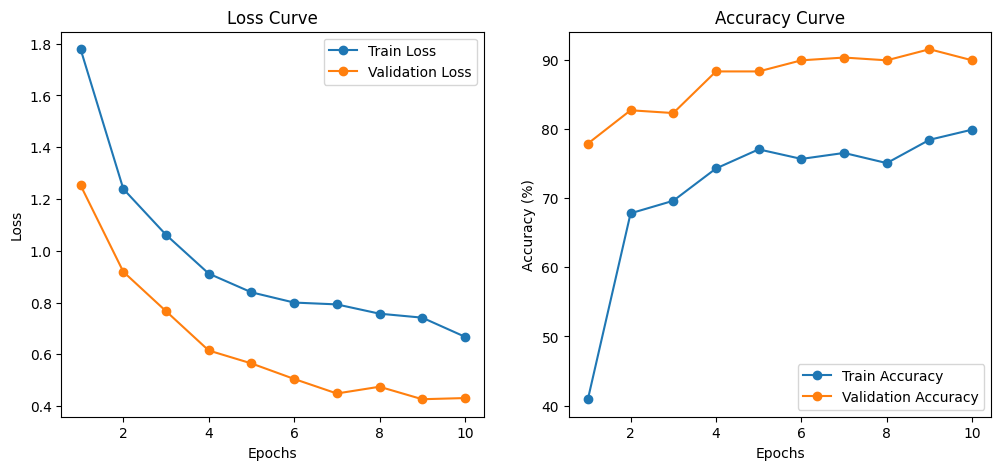

In [ ]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


###Test Loop & Predictions

In [ ]:
# 🔹 Test loop for predictions
model.eval()  # set model to evaluation mode
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)           # logits: [batch_size, 9]
        _, preds = torch.max(outputs, 1)  # predicted class index

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Date classes
classes = ['Ajwa', 'Galaxy', 'Medjool', 'Meneifi', 'Nabtat Ali',
           'Rutab', 'Shaishe', 'Sokari', 'Sugaey']

# Print predictions vs actual
for i in range(len(all_labels)):
    print(f"Actual: {classes[all_labels[i]]}  |  Predicted: {classes[all_preds[i]]}")

###Save Trained Model

In [ ]:
from pathlib import Path

BASE_DIR = Path().resolve().parent  # go from notebooks -> ai
MODEL_PATH = BASE_DIR / "models" / "nakhlah_model_v1.pth"

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved to {MODEL_PATH}")